# Cell Voltage Exploratory Data Analysis
**Date:** 2026-03-11 | **Session duration:** 124 secs | **Pack:** 84-cell

## Summary
Pack behavior indicates a critical cell fault requiring immediate attention.
See conclusions for details.

**Imports & configs**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bms_utils as B

B.apply_lsu_style()
PATH = '../data/raw/cellvoltages_2026-03-11-15-48-37.csv'

**Load**

In [2]:
df = B.load_session(PATH)
print(f'Duration: {df["elapsed_s"].max():.0f} sec  ({len(df)} rows)')
print(df.isnull().sum().sum(), 'total missing values')
df.head()

Duration: 124 sec  (191 rows)
0 total missing values


,Time,State of Charge,Pack Voltage,Pack Current,Pack CCL,Pack DCL,Highest Cell ID,Highest Cell Volt,Lowest Cell ID,Lowest Cell Volt,...,Open Cell Voltage 77,Open Cell Voltage 78,Open Cell Voltage 79,Open Cell Voltage 80,Open Cell Voltage 81,Open Cell Voltage 82,Open Cell Voltage 83,Open Cell Voltage 84,elapsed_s,session_id
0,2026-03-11 15:48:41,50.0,303.0,-0.0,6,198,82,3.6098,9,3.5939,...,3.609,3.6096,3.6081,3.6083,3.6081,3.6096,3.6084,3.6072,0.0,2026-03-11-15-48-37
1,2026-03-11 15:48:42,50.0,303.0,0.2,6,198,23,3.6097,9,3.5940,...,3.609,3.6096,3.6081,3.6083,3.6081,3.6096,3.6084,3.6072,1.0,2026-03-11-15-48-37
2,2026-03-11 15:48:42,50.0,303.0,-0.0,6,198,39,3.6097,9,3.5940,...,3.609,3.6096,3.6081,3.6083,3.6081,3.6096,3.6084,3.6072,1.0,2026-03-11-15-48-37
3,2026-03-11 15:48:43,50.0,303.0,-0.0,6,198,39,3.6098,9,3.5939,...,3.609,3.6096,3.6081,3.6083,3.6081,3.6096,3.6084,3.6072,2.0,2026-03-11-15-48-37
4,2026-03-11 15:48:44,50.0,303.0,0.2,6,198,82,3.6097,9,3.5941,...,3.609,3.6096,3.6081,3.6083,3.6081,3.6096,3.6084,3.6072,3.0,2026-03-11-15-48-37


**Pack Current & Voltage Over Time**

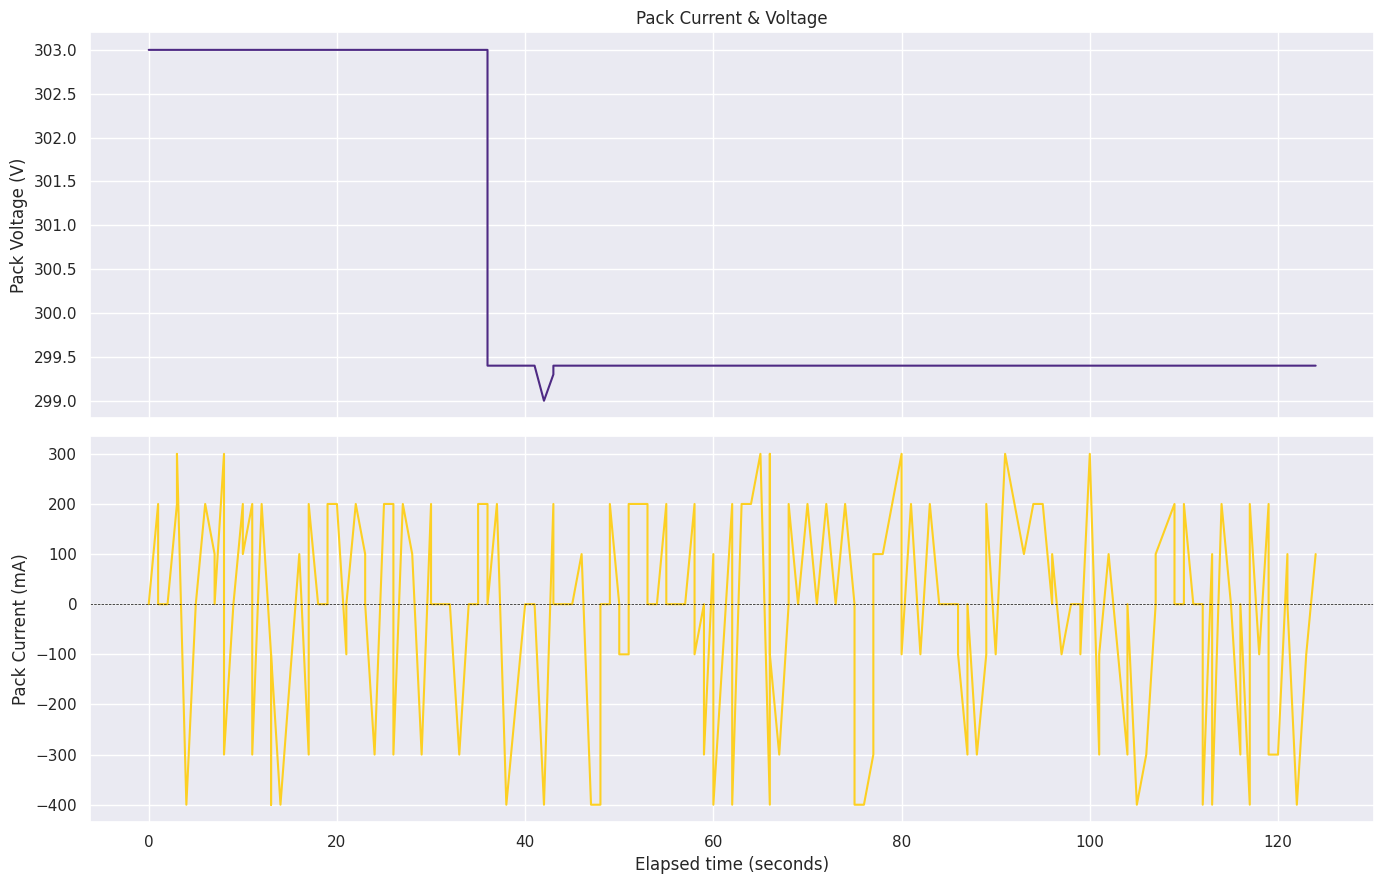

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
axes[0].plot(df['elapsed_s'], df['Pack Voltage'])
axes[0].set_ylabel('Pack Voltage (V)')
axes[0].set_title('Pack Current & Voltage')
axes[1].plot(df['elapsed_s'], df['Pack Current'] * 1000, color='#FDD023')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_ylabel('Pack Current (mA)')
axes[1].set_xlabel('Elapsed time (seconds)')
plt.tight_layout()
plt.show()

**Voltage Spread Over Time**

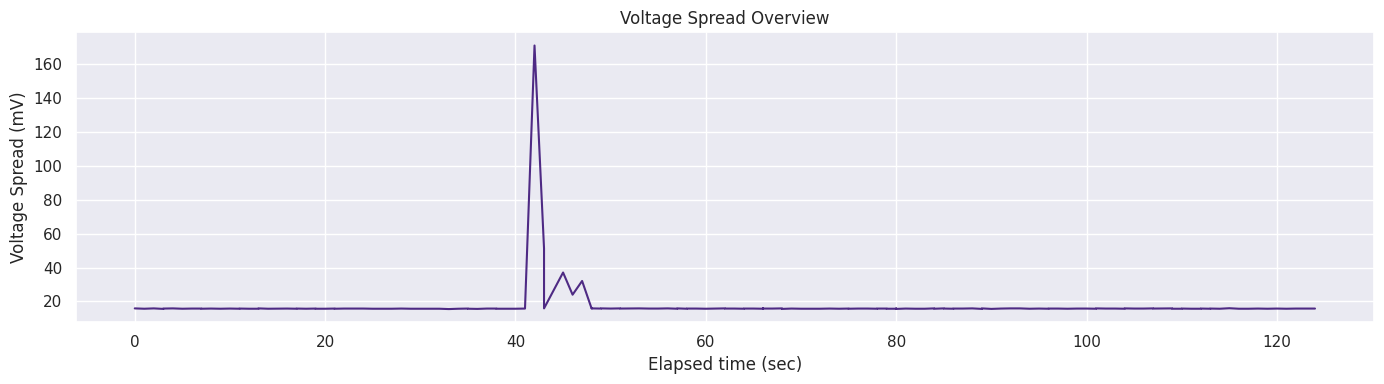

In [4]:
df['Voltage Spread'] = df['Highest Cell Volt'] - df['Lowest Cell Volt']
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
ax.plot(df['elapsed_s'], df['Voltage Spread'] * 1000)
ax.set_title('Voltage Spread Overview')
ax.set_ylabel('Voltage Spread (mV)')
ax.set_xlabel('Elapsed time (sec)')
plt.tight_layout()
plt.show()

**Mean Voltage And Mean Rank Per Cell**

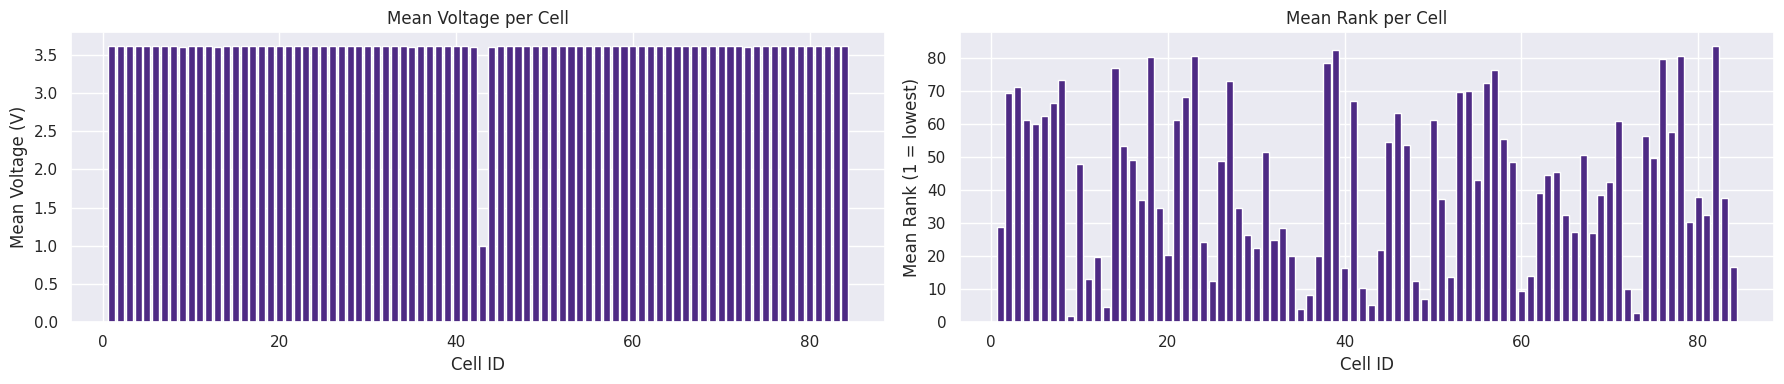

In [5]:
cell_mean_voltage = B.cell_mean_voltage(df)
cell_mean_rank = B.cell_mean_rank(df)
CELL_IDS = range(1, B.N_CELLS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 4))
ax1.bar(CELL_IDS, cell_mean_voltage)
ax1.set_title('Mean Voltage per Cell')
ax1.set_xlabel('Cell ID')
ax1.set_ylabel('Mean Voltage (V)')

ax2.bar(CELL_IDS, cell_mean_rank)
ax2.set_title('Mean Rank per Cell')
ax2.set_xlabel('Cell ID')
ax2.set_ylabel('Mean Rank (1 = lowest)')

plt.tight_layout()
plt.show()

**Mean Cell Rank Distribution**

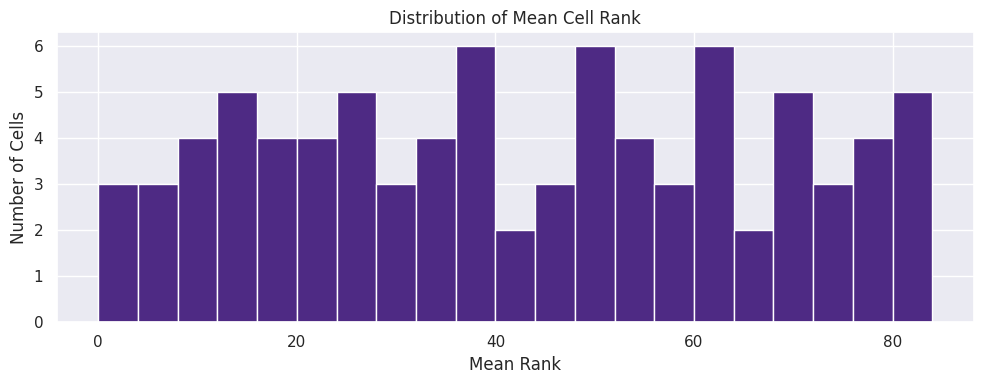

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cell_mean_rank, bins=range(0, 85, 4))
ax.set_title('Distribution of Mean Cell Rank')
ax.set_xlabel('Mean Rank')
ax.set_ylabel('Number of Cells')
plt.tight_layout()
plt.show()

**Cell Voltage By Z-Score**

Most-below pack mean (z-score):
Cell Voltage 43   -9.056
Cell Voltage 9     0.060
Cell Voltage 73    0.088
Cell Voltage 35    0.091
Cell Voltage 13    0.091
dtype: float64

Most-above pack mean (z-score):
Cell Voltage 82    0.115
Cell Voltage 39    0.115
Cell Voltage 78    0.115
Cell Voltage 23    0.115
Cell Voltage 18    0.115
dtype: float64


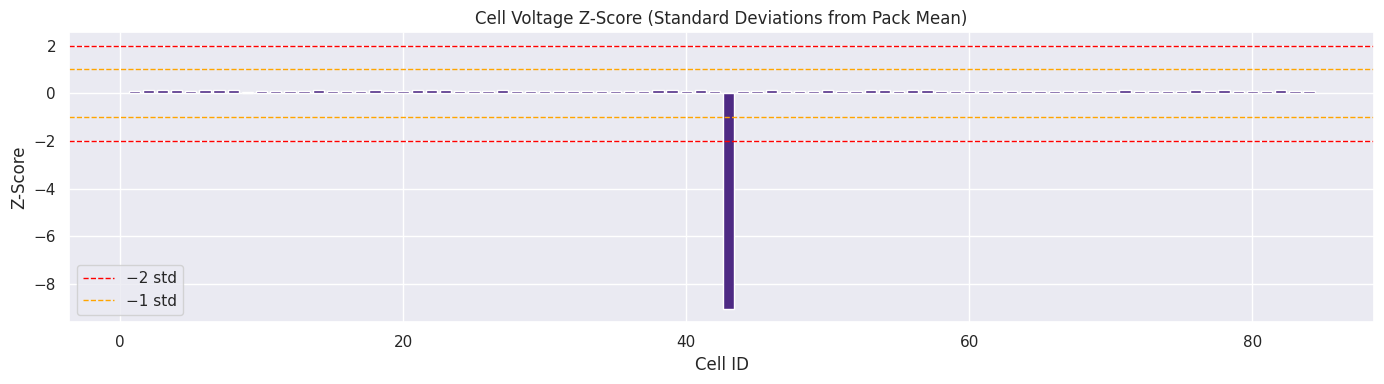

In [7]:
z_scores = B.cell_voltage_z(df)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(1, B.N_CELLS + 1), z_scores)
ax.axhline(-2, color='red',    linestyle='--', linewidth=1, label='−2 std')
ax.axhline(-1, color='orange', linestyle='--', linewidth=1, label='−1 std')
ax.axhline( 1, color='orange', linestyle='--', linewidth=1)
ax.axhline( 2, color='red',    linestyle='--', linewidth=1)
ax.set_title('Cell Voltage Z-Score (Standard Deviations from Pack Mean)')
ax.set_xlabel('Cell ID')
ax.set_ylabel('Z-Score')
ax.legend()

print('Most-below pack mean (z-score):')
print(z_scores.nsmallest(5).round(3))
print('\nMost-above pack mean (z-score):')
print(z_scores.nlargest(5).round(3))
plt.tight_layout()
plt.show()

**Voltage Of Special Cells Vs Pack Mean Voltage**

Mean Voltage of Weakest Cells (V)
Cell Voltage 43    1.0010
Cell Voltage 9     3.5940
Cell Voltage 73    3.6019
Cell Voltage 35    3.6027
Cell Voltage 13    3.6028
dtype: float64

Mean Rank of Weakest Cells (1-84)
Cell Voltage 9     1.77
Cell Voltage 73    2.77
Cell Voltage 35    3.93
Cell Voltage 13    4.62
Cell Voltage 43    5.25
dtype: float64


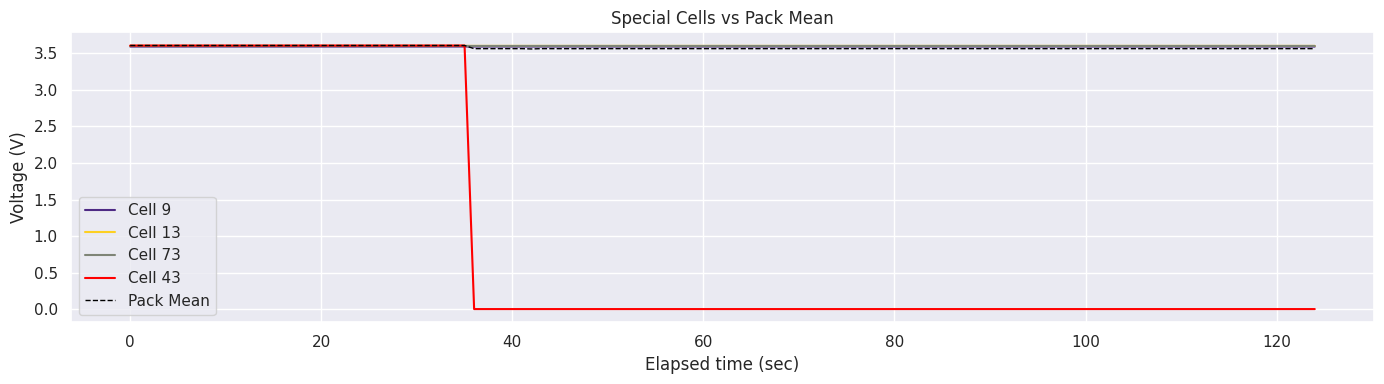

In [8]:
print('Mean Voltage of Weakest Cells (V)')
print(cell_mean_voltage.nsmallest(5).round(4))
print('\nMean Rank of Weakest Cells (1-84)')
print(cell_mean_rank.nsmallest(5).round(2))

pack_mean = df[B.CV_COLS].mean(axis=1)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['elapsed_s'], df['Cell Voltage 9'],  label='Cell 9')
ax.plot(df['elapsed_s'], df['Cell Voltage 13'], label='Cell 13')
ax.plot(df['elapsed_s'], df['Cell Voltage 73'], label='Cell 73')
ax.plot(df['elapsed_s'], df['Cell Voltage 43'], label='Cell 43', color='red')
ax.plot(df['elapsed_s'], pack_mean, label='Pack Mean', color='black', linestyle='--', linewidth=1)
ax.set_title('Special Cells vs Pack Mean')
ax.set_xlabel('Elapsed time (sec)')
ax.set_ylabel('Voltage (V)')
ax.legend()
plt.tight_layout()
plt.show()

## Conclusion
### **Pack Health Overview**
The pack voltage drops sharply at t ≈ 36 s from ~303 V to ~299.5 V before
stabilizing, likely reflecting a BMS response to the Cell 43 fault. Pack
current is erratic and oscillating throughout the session.

### **Cell 43**
Cell 43 voltage collapses to near 0 V at t ≈ 36 s and remains that value for
the duration of the session, registering ~−9.1 standard deviations from pack
mean. Notably, cell 43 was anomalously high at +6.9 standard deviations in
session 1. This reversal from overperformance to near-zero voltage across two
sessions is consistent with accelerated degradation, possibly caused by
overcharging. Cell 43 should be escalated to senior team members for physical
inspection immediately.

### **Notes & Next Steps**
**Note:** Cell 43's behavior across both sessions — anomalously high voltage in
session 1 followed by near-zero voltage in session 2 — is sufficient to draw
firm conclusions without further sessions. Pack current never exceeds ~0.4 A in
this 124-second window, so the load-residual diagnostic isn't meaningful here
and is omitted; cross-session inference is instead handled by `trends.ipynb`.

**Next steps:** Escalate cell 43 for physical inspection before further charging.
Cells 9, 13, and 73 could not be meaningfully evaluated this session due to
cell 43 dominating pack statistics; re-examine in a future session once pack
behavior normalizes.